
Decision Tree Regressor
MSE: 42.58102330097088
R² Score: 0.8347503240203619

Bagging Regressor
MSE: 30.907845576669413
R² Score: 0.8800519322733877


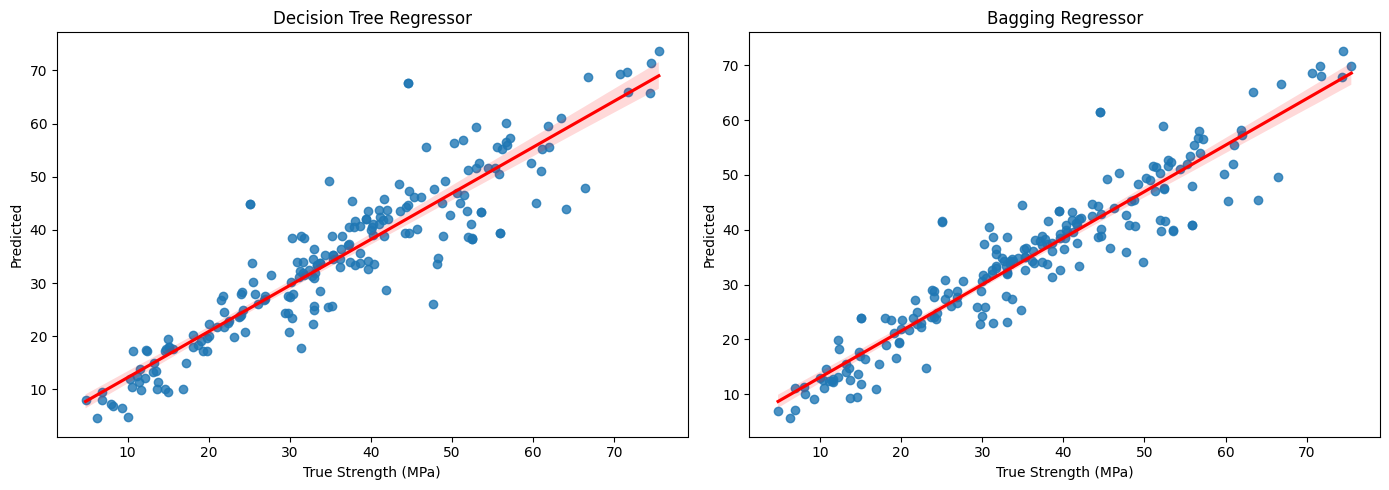

'Output -\nDecision Tree Regressor\nMSE: 42.58102330097088\nR² Score: 0.8347503240203619\nBagging Regressor\nMSE: 30.907845576669413\nR² Score: 0.8800519322733877\n'

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
# 1. Fetch dataset
concrete_data = fetch_ucirepo(id=165)  # Concrete Compressive Strength
# 2. Get features and target
X = concrete_data.data.features
y = concrete_data.data.targets.iloc[:, 0]  # single column
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 4. Optional: scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 5. Single Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
# 6. Bagging Regressor (estimator = DT)
bag = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)
bag.fit(X_train_scaled, y_train)
y_pred_bag = bag.predict(X_test_scaled)
# 7. Evaluation
def evaluate(name, y_true, y_pred):
   print(f"\n{name}")
   print("MSE:", mean_squared_error(y_true, y_pred))
   print("R² Score:", r2_score(y_true, y_pred))
evaluate("Decision Tree Regressor", y_test, y_pred_dt)
evaluate("Bagging Regressor", y_test, y_pred_bag)
# 8. Plot predictions
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_pred_dt, line_kws={"color": "red"})
plt.title("Decision Tree Regressor")
plt.xlabel("True Strength (MPa)")
plt.ylabel("Predicted")
plt.subplot(1, 2, 2)
sns.regplot(x=y_test, y=y_pred_bag, line_kws={"color": "red"})
plt.title("Bagging Regressor")
plt.xlabel("True Strength (MPa)")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()
'''Output -
Decision Tree Regressor
MSE: 42.58102330097088
R² Score: 0.8347503240203619
Bagging Regressor
MSE: 30.907845576669413
R² Score: 0.8800519322733877
'''